# GhostNet Face Recognition Training
This notebook trains GhostNet for face recognition with regularization techniques

In [1]:
import torch
import torch.nn as nn
import timm  # GhostNet is available through timm library

# Install timm if not already installed
# !pip install timm

# Load GhostNet pretrained on ImageNet
# GhostNet is a very lightweight model designed for mobile deployment
ghostnet = timm.create_model('ghostnet_100', pretrained=True)
print(f"GhostNet loaded successfully")
print(f"Model: {ghostnet.__class__.__name__}")

c:\Users\cagan\AppData\Local\Programs\Python\Python310\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Users\cagan\AppData\Local\Programs\Python\Python310\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may

GhostNet loaded successfully
Model: GhostNet


c:\Users\cagan\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\cagan\.cache\huggingface\hub\models--timm--ghostnet_100.in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [2]:
from collections import defaultdict

import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset


# Training transform WITH AGGRESSIVE DATA AUGMENTATION (to prevent overfitting)
train_transform = transforms.Compose([
    transforms.Resize(256),                    # Resize to 256x256
    transforms.RandomCrop(224),                # Randomly crop to 224x224
    transforms.RandomHorizontalFlip(p=0.5),    # 50% chance to flip horizontally
    transforms.RandomRotation(degrees=30),     # Rotate randomly ±30 degrees
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),  # Aggressive color jitter
    transforms.RandomGrayscale(p=0.3),         # 30% chance to convert to grayscale
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # Perspective changes
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),   # Random shifts
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),   # Blur
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1)),         # Random occlusion
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation/Test transform WITHOUT augmentation (just normalize)
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ============== STEP 2: LOAD DATASET (NO TRANSFORM YET) ==============
# We'll apply transforms later per split

full_dataset_no_transform = datasets.ImageFolder(root='../../dataset/ClientFace')

# ============== STEP 3: PROPER SPLIT BY CLASS/PERSON ==============

def split_dataset_by_class(dataset, train_ratio=0.7, val_ratio=0.15):
    """
    Split dataset ensuring images of the same person stay together
    This PREVENTS DATA LEAKAGE
    """
    # Group indices by class (person)
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.imgs):
        class_indices[label].append(idx)
    
    train_indices = []
    val_indices = []
    test_indices = []
    
    # Split each person's images separately
    for class_label, indices in class_indices.items():
        n_samples = len(indices)
        n_train = int(train_ratio * n_samples)
        n_val = int(val_ratio * n_samples)
        
        # Shuffle this person's images
        np.random.shuffle(indices)
        
        # Distribute images
        train_indices.extend(indices[:n_train])
        val_indices.extend(indices[n_train:n_train + n_val])
        test_indices.extend(indices[n_train + n_val:])
    
    # Print split info
    print("Dataset Split Summary:")
    print("=" * 60)
    for class_label, indices in class_indices.items():
        class_name = dataset.classes[class_label]
        n_total = len(indices)
        n_train = int(train_ratio * n_total)
        n_val = int(val_ratio * n_total)
        n_test = n_total - n_train - n_val
        print(f"{class_name:15} -> Train: {n_train:3}, Val: {n_val:3}, Test: {n_test:3}, Total: {n_total:3}")
    print("=" * 60)
    
    return train_indices, val_indices, test_indices

# Get indices for each split
train_indices, val_indices, test_indices = split_dataset_by_class(
    full_dataset_no_transform,
    train_ratio=0.7,
    val_ratio=0.15
)

# ============== STEP 4: CREATE DATASETS WITH DIFFERENT TRANSFORMS ==============

# Create dataset copies with appropriate transforms
train_dataset_full = datasets.ImageFolder(root='../../dataset/ClientFace', transform=train_transform)
val_dataset_full = datasets.ImageFolder(root='../../dataset/ClientFace', transform=test_transform)
test_dataset_full = datasets.ImageFolder(root='../../dataset/ClientFace', transform=test_transform)

# Apply the splits
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)
test_dataset = Subset(test_dataset_full, test_indices)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nFinal Split: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

# ============== STEP 5: MODEL SETUP ==============

ghostnet = timm.create_model('ghostnet_100', pretrained=True)
num_classes = len(full_dataset_no_transform.classes)
class_names = full_dataset_no_transform.classes

print(f"\nNumber of classes (people): {num_classes}")
print(f"Class names: {class_names}")

# Get the original classifier structure
print(f"\nOriginal classifier: {ghostnet.classifier}")

# GhostNet classifier structure:
# Sequential(
#   (0): Linear(in_features=1280, out_features=1000, bias=True)
# )

# Add dropout and replace classifier
num_features = ghostnet.classifier.in_features
ghostnet.classifier = nn.Sequential(
    nn.Dropout(p=0.5),  # Add dropout to prevent overfitting
    nn.Linear(num_features, num_classes)
)

print(f"\nOriginal features: {num_features}")
print(f"Modified classifier (with dropout): {ghostnet.classifier}")

Dataset Split Summary:
0001            -> Train: 174, Val:  37, Test:  38, Total: 249
0002            -> Train:  39, Val:   8, Test:  10, Total:  57
0003            -> Train:  79, Val:  16, Test:  18, Total: 113
0004            -> Train: 476, Val: 102, Test: 103, Total: 681
0005            -> Train: 133, Val:  28, Test:  29, Total: 190
0006            -> Train: 510, Val: 109, Test: 111, Total: 730
0007            -> Train: 533, Val: 114, Test: 115, Total: 762
0008            -> Train:  86, Val:  18, Test:  19, Total: 123
0009            -> Train: 149, Val:  31, Test:  33, Total: 213
0010            -> Train:  53, Val:  11, Test:  12, Total:  76
0011            -> Train: 286, Val:  61, Test:  62, Total: 409
0012            -> Train: 304, Val:  65, Test:  66, Total: 435
0013            -> Train: 330, Val:  70, Test:  72, Total: 472
0014            -> Train: 333, Val:  71, Test:  73, Total: 477
0015            -> Train:  82, Val:  17, Test:  19, Total: 118

Final Split: Train=3567, Val=75

In [ ]:
import torch.optim as optim


# Setup training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ghostnet = ghostnet.to(device)

criterion = nn.CrossEntropyLoss()

# Optimizer with weight decay (L2 regularization) to prevent overfitting
optimizer = optim.Adam(
    ghostnet.parameters(), 
    lr=0.003,  # Lower learning rate
    weight_decay=0.0003  # L2 regularization
)

# Training with tracking and early stopping
num_epochs = 2  # Increased max epochs, but early stopping will prevent overtraining
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float('inf')
best_val_acc = 0.0
patience = 5  # Stop if no improvement for 5 epochs
patience_counter = 0

print(f"\nTraining Configuration:")
print(f"  Model: GhostNet-100")
print(f"  Device: {device}")
print(f"  Max Epochs: {num_epochs}")
print(f"  Learning Rate: 0.001")
print(f"  Weight Decay: 0.0001")
print(f"  Dropout: 0.5")
print(f"  Early Stopping Patience: {patience}")
print("\n" + "="*60)

for epoch in range(num_epochs):
    # Training phase
    ghostnet.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = ghostnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validation phase
    ghostnet.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = ghostnet(inputs)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(ghostnet.state_dict(), 'ghostnet_best.pth')
        print(f'Epoch {epoch+1}/{num_epochs} - '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% ✅ BEST MODEL SAVED')
    else:
        patience_counter += 1
        print(f'Epoch {epoch+1}/{num_epochs} - '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% (Patience: {patience_counter}/{patience})')
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
        print(f"Best validation accuracy: {best_val_acc:.2f}%")
        print(f"Best validation loss: {best_val_loss:.4f}")
        break

# Load best model for evaluation
print("\nLoading best model for evaluation...")
ghostnet.load_state_dict(torch.load('ghostnet_best.pth'))
print(f"Best model loaded (Val Acc: {best_val_acc:.2f}%)")


Training Configuration:
  Model: GhostNet-100
  Device: cuda
  Max Epochs: 2
  Learning Rate: 0.001
  Weight Decay: 0.0001
  Dropout: 0.5
  Early Stopping Patience: 5

Epoch 1/2 - Train Loss: 0.1031, Train Acc: 97.65% - Val Loss: 0.0039, Val Acc: 100.00% ✅ BEST MODEL SAVED
Epoch 2/2 - Train Loss: 0.0415, Train Acc: 98.93% - Val Loss: 0.0668, Val Acc: 98.81% (Patience: 1/5)

Loading best model for evaluation...
Best model loaded (Val Acc: 100.00%)


: 

In [15]:
# Save final model (already saved best during training)
torch.save(ghostnet.state_dict(), 'ghostnet_face_recognition.pth')
print("Final model saved as 'ghostnet_face_recognition.pth'")
print(f"(This is the best model from training with Val Acc: {best_val_acc:.2f}%)")

Final model saved as 'ghostnet_face_recognition.pth'
(This is the best model from training with Val Acc: 99.87%)


In [16]:
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    cohen_kappa_score, matthews_corrcoef
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

def comprehensive_evaluation(model, data_loader, device, class_names):
    """
    Complete evaluation metrics for thesis
    """
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_probabilities = []
    inference_times = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Measure inference time
            start_time = time()
            outputs = model(inputs)
            inference_time = time() - start_time
            inference_times.append(inference_time / len(inputs))  # Per image
            
            # Get predictions and probabilities
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    # ============== CALCULATE ALL METRICS ==============
    
    # 1. Basic Metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    
    # 2. Per-class metrics (macro = average across classes, weighted = weighted by support)
    precision_macro = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
    precision_weighted = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    
    recall_macro = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
    recall_weighted = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
    
    f1_macro = f1_score(all_labels, all_predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)
    
    # 3. Advanced metrics
    kappa = cohen_kappa_score(all_labels, all_predictions)
    mcc = matthews_corrcoef(all_labels, all_predictions)
    
    # 4. Per-class detailed metrics
    precision_per_class = precision_score(all_labels, all_predictions, average=None, zero_division=0)
    recall_per_class = recall_score(all_labels, all_predictions, average=None, zero_division=0)
    f1_per_class = f1_score(all_labels, all_predictions, average=None, zero_division=0)
    
    # 5. Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # 6. Top-k Accuracy
    top3_acc = top_k_accuracy(all_probabilities, all_labels, k=3)
    top5_acc = top_k_accuracy(all_probabilities, all_labels, k=5)
    
    # 7. Performance metrics
    avg_inference_time = np.mean(inference_times) * 1000  # Convert to ms
    std_inference_time = np.std(inference_times) * 1000
    
    # 8. Confidence metrics
    confidence_scores = np.max(all_probabilities, axis=1)
    avg_confidence = np.mean(confidence_scores)
    std_confidence = np.std(confidence_scores)
    
    # ============== PRINT RESULTS ==============
    
    print("=" * 80)
    print("COMPREHENSIVE MODEL EVALUATION METRICS")
    print("=" * 80)
    
    print("\n📊 OVERALL PERFORMANCE METRICS")
    print("-" * 80)
    print(f"Accuracy:                    {accuracy * 100:.2f}%")
    print(f"Precision (Macro):           {precision_macro * 100:.2f}%")
    print(f"Precision (Weighted):        {precision_weighted * 100:.2f}%")
    print(f"Recall (Macro):              {recall_macro * 100:.2f}%")
    print(f"Recall (Weighted):           {recall_weighted * 100:.2f}%")
    print(f"F1-Score (Macro):            {f1_macro * 100:.2f}%")
    print(f"F1-Score (Weighted):         {f1_weighted * 100:.2f}%")
    print(f"Cohen's Kappa:               {kappa:.4f}")
    print(f"Matthews Correlation Coef:   {mcc:.4f}")
    
    print("\n🎯 TOP-K ACCURACY")
    print("-" * 80)
    print(f"Top-3 Accuracy:              {top3_acc * 100:.2f}%")
    print(f"Top-5 Accuracy:              {top5_acc * 100:.2f}%")
    
    print("\n⚡ INFERENCE PERFORMANCE")
    print("-" * 80)
    print(f"Avg Inference Time:          {avg_inference_time:.2f} ms/image")
    print(f"Std Inference Time:          {std_inference_time:.2f} ms")
    print(f"Throughput:                  {1000/avg_inference_time:.2f} images/second")
    
    print("\n🎲 PREDICTION CONFIDENCE")
    print("-" * 80)
    print(f"Average Confidence:          {avg_confidence * 100:.2f}%")
    print(f"Std Confidence:              {std_confidence * 100:.2f}%")
    print(f"Min Confidence:              {np.min(confidence_scores) * 100:.2f}%")
    print(f"Max Confidence:              {np.max(confidence_scores) * 100:.2f}%")
    
    print("\n📈 PER-CLASS METRICS")
    print("-" * 80)
    print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 80)
    
    for i, class_name in enumerate(class_names):
        support = np.sum(all_labels == i)
        print(f"{class_name:<20} {precision_per_class[i]*100:>10.2f}% "
              f"{recall_per_class[i]*100:>10.2f}% {f1_per_class[i]*100:>10.2f}% "
              f"{support:>10}")
    
    # ============== RETURN DICTIONARY FOR FURTHER USE ==============
    
    results = {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'precision_weighted': precision_weighted,
        'recall_macro': recall_macro,
        'recall_weighted': recall_weighted,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'cohen_kappa': kappa,
        'matthews_corrcoef': mcc,
        'top3_accuracy': top3_acc,
        'top5_accuracy': top5_acc,
        'avg_inference_time_ms': avg_inference_time,
        'std_inference_time_ms': std_inference_time,
        'throughput_imgs_per_sec': 1000/avg_inference_time,
        'avg_confidence': avg_confidence,
        'std_confidence': std_confidence,
        'confusion_matrix': cm,
        'per_class_precision': precision_per_class,
        'per_class_recall': recall_per_class,
        'per_class_f1': f1_per_class,
        'all_predictions': all_predictions,
        'all_labels': all_labels,
        'all_probabilities': all_probabilities
    }
    
    return results

def top_k_accuracy(probabilities, labels, k=3):
    """Calculate top-k accuracy"""
    top_k_preds = np.argsort(probabilities, axis=1)[:, -k:]
    correct = sum([labels[i] in top_k_preds[i] for i in range(len(labels))])
    return correct / len(labels)

In [18]:
def plot_confusion_matrix(cm, class_names, save_path='confusion_matrix_ghostnet.png'):
    """Plot and save confusion matrix"""
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - GhostNet', fontsize=16)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to {save_path}")

def plot_per_class_metrics(results, class_names, save_path='per_class_metrics_ghostnet.png'):
    """Plot per-class precision, recall, F1"""
    x = np.arange(len(class_names))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    bars1 = ax.bar(x - width, results['per_class_precision'] * 100, width, label='Precision')
    bars2 = ax.bar(x, results['per_class_recall'] * 100, width, label='Recall')
    bars3 = ax.bar(x + width, results['per_class_f1'] * 100, width, label='F1-Score')
    
    ax.set_xlabel('Classes', fontsize=12)
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title('Per-Class Performance Metrics - GhostNet', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Per-class metrics saved to {save_path}")

def plot_training_history(train_losses, val_losses, train_accs, val_accs, save_path='training_history_ghostnet.png'):
    """Plot training and validation metrics over epochs"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(train_losses) + 1)
    
    # Loss plot
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss - GhostNet', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title('Training and Validation Accuracy - GhostNet', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Training history saved to {save_path}")

def generate_classification_report_txt(results, class_names, save_path='classification_report_ghostnet.txt'):
    """Save detailed text report"""
    with open(save_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("DETAILED CLASSIFICATION REPORT - GhostNet\n")
        f.write("=" * 80 + "\n\n")
        
        f.write("OVERALL METRICS\n")
        f.write("-" * 80 + "\n")
        f.write(f"Accuracy:                    {results['accuracy'] * 100:.2f}%\n")
        f.write(f"Precision (Macro):           {results['precision_macro'] * 100:.2f}%\n")
        f.write(f"Recall (Macro):              {results['recall_macro'] * 100:.2f}%\n")
        f.write(f"F1-Score (Macro):            {results['f1_macro'] * 100:.2f}%\n")
        f.write(f"Cohen's Kappa:               {results['cohen_kappa']:.4f}\n")
        f.write(f"Matthews Correlation Coef:   {results['matthews_corrcoef']:.4f}\n\n")
        
        f.write("PER-CLASS METRICS\n")
        f.write("-" * 80 + "\n")
        for i, class_name in enumerate(class_names):
            f.write(f"\nClass: {class_name}\n")
            f.write(f"  Precision: {results['per_class_precision'][i] * 100:.2f}%\n")
            f.write(f"  Recall:    {results['per_class_recall'][i] * 100:.2f}%\n")
            f.write(f"  F1-Score:  {results['per_class_f1'][i] * 100:.2f}%\n")
    
    print(f"Classification report saved to {save_path}")


EVALUATING ON TEST SET - GhostNet
COMPREHENSIVE MODEL EVALUATION METRICS

📊 OVERALL PERFORMANCE METRICS
--------------------------------------------------------------------------------
Accuracy:                    99.87%
Precision (Macro):           99.67%
Precision (Weighted):        99.88%
Recall (Macro):              99.94%
Recall (Weighted):           99.87%
F1-Score (Macro):            99.80%
F1-Score (Weighted):         99.87%
Cohen's Kappa:               0.9986
Matthews Correlation Coef:   0.9986

🎯 TOP-K ACCURACY
--------------------------------------------------------------------------------
Top-3 Accuracy:              100.00%
Top-5 Accuracy:              100.00%

⚡ INFERENCE PERFORMANCE
--------------------------------------------------------------------------------
Avg Inference Time:          0.51 ms/image
Std Inference Time:          0.66 ms
Throughput:                  1949.79 images/second

🎲 PREDICTION CONFIDENCE
-------------------------------------------------------

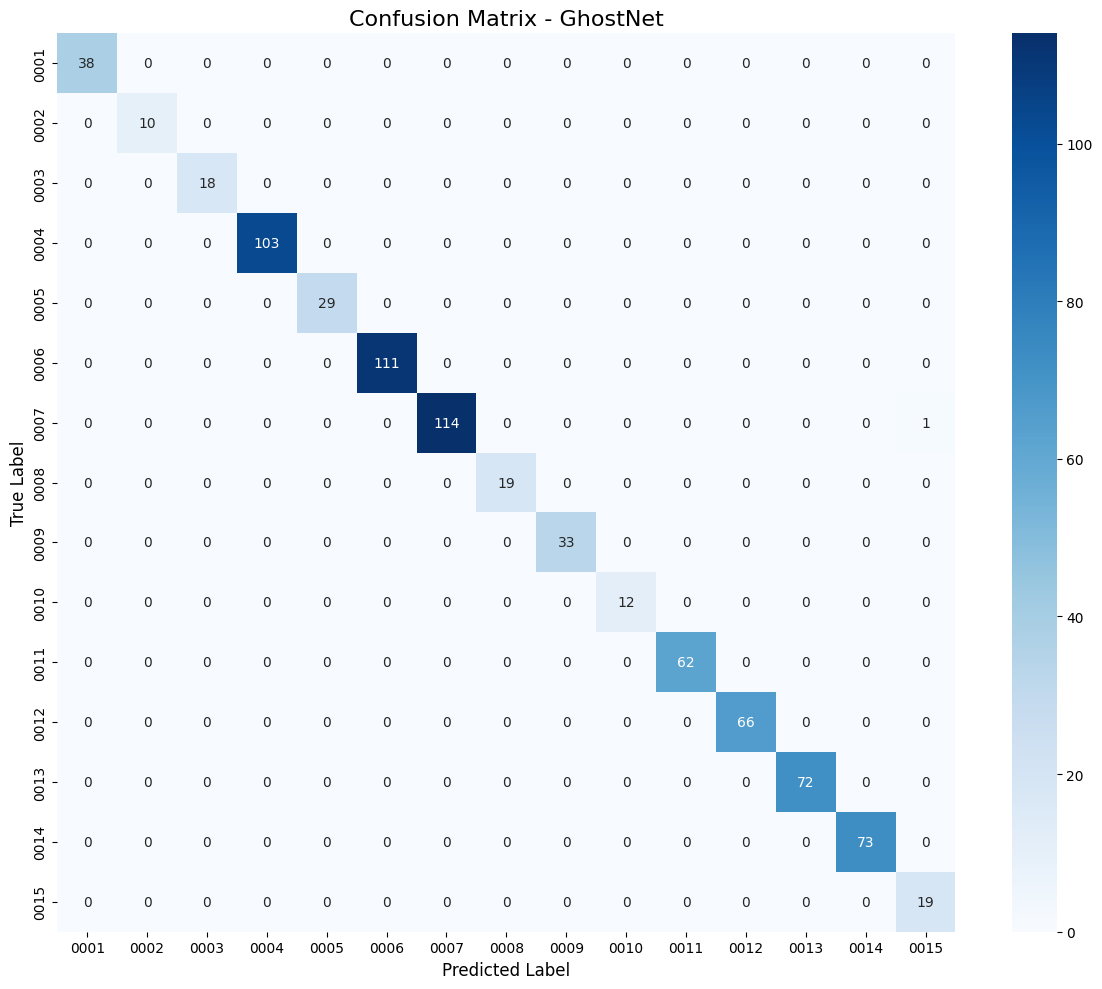

Confusion matrix saved to confusion_matrix_ghostnet.png


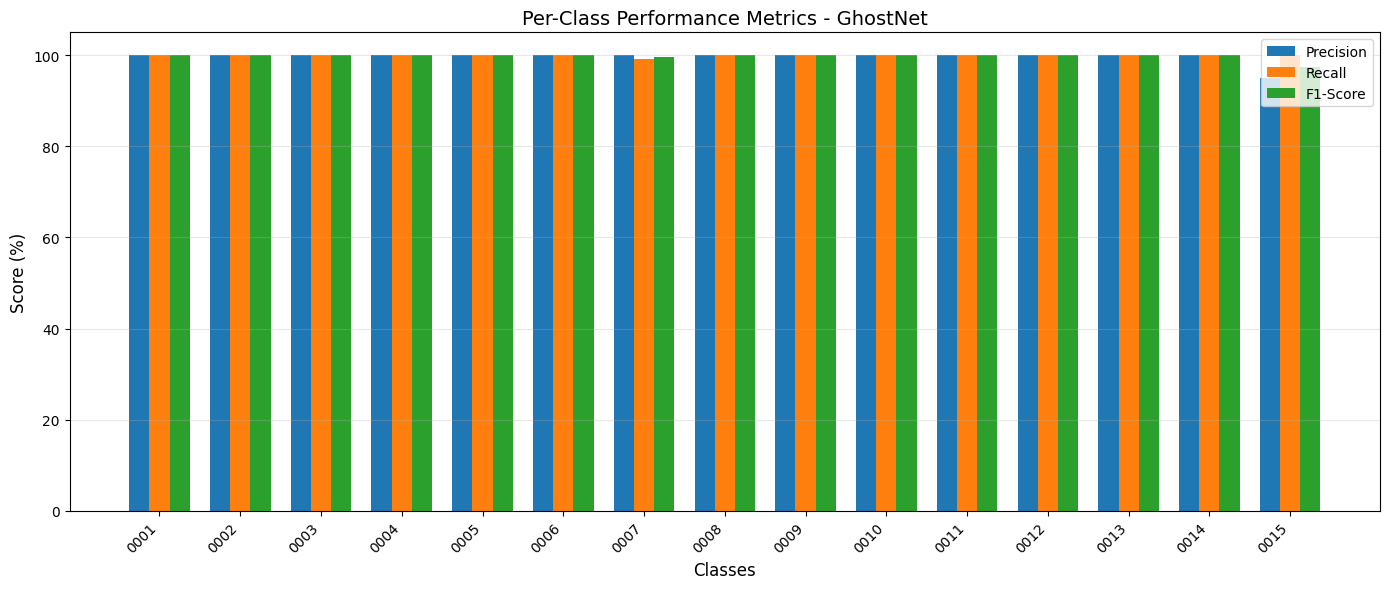

Per-class metrics saved to per_class_metrics_ghostnet.png


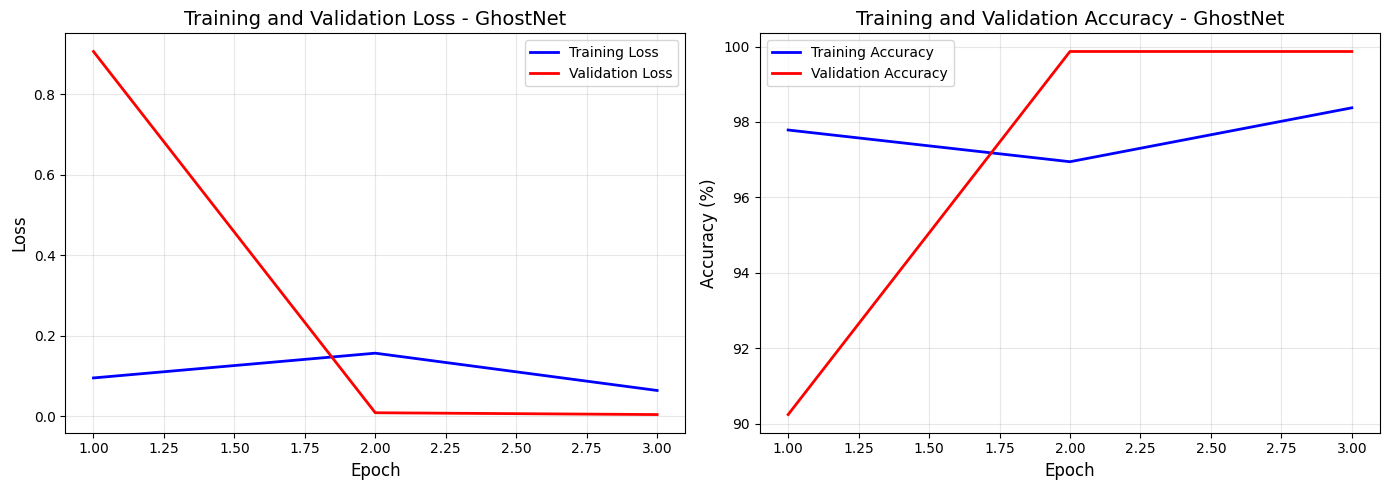

Training history saved to training_history_ghostnet.png
Classification report saved to classification_report_ghostnet.txt

✅ All evaluation metrics and visualizations saved!


In [19]:
# Comprehensive evaluation on test set
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET - GhostNet")
print("=" * 80)

results = comprehensive_evaluation(ghostnet, test_loader, device, class_names)

# Generate visualizations
plot_confusion_matrix(results['confusion_matrix'], class_names)
plot_per_class_metrics(results, class_names)
plot_training_history(train_losses, val_losses, train_accs, val_accs)
generate_classification_report_txt(results, class_names)

print("\n✅ All evaluation metrics and visualizations saved!")

In [20]:
import os
import random
from PIL import Image

def load_trained_model(model_path="ghostnet_face_recognition.pth", num_classes=15, device='cpu'):
    """Load the trained GhostNet model"""
    model = timm.create_model('ghostnet_100', pretrained=False)
    # Recreate the same architecture with dropout
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_features, num_classes)
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

def get_random_image_from_dataset(dataset_path):
    """Randomly select an image from the dataset"""
    # Get all class folders
    class_folders = [f for f in os.listdir(dataset_path) 
                     if os.path.isdir(os.path.join(dataset_path, f))]
    
    # Randomly select a class
    random_class = random.choice(class_folders)
    class_path = os.path.join(dataset_path, random_class)
    
    # Get all images in that class folder
    image_files = [f for f in os.listdir(class_path) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    
    # Randomly select an image
    random_image = random.choice(image_files)
    image_path = os.path.join(class_path, random_image)
    
    return image_path, random_class

def classify_image(model, image_path, class_names, device, transform):
    """Classify a single image and return predictions"""
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Get predictions
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
        # Get top 5 predictions
        top5_prob, top5_idx = torch.topk(probabilities, min(5, len(class_names)))
        top5_prob = top5_prob.cpu().numpy()[0]
        top5_idx = top5_idx.cpu().numpy()[0]
    
    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item()
    
    return image, predicted_class, confidence_score, top5_prob, top5_idx

def visualize_prediction(image, true_label, predicted_label, confidence, 
                         top5_probs, top5_indices, class_names, save_path=None):
    """Visualize the image with prediction results"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Display image
    ax1.imshow(image)
    ax1.axis('off')
    
    # Title with prediction
    color = 'green' if true_label == predicted_label else 'red'
    title = f'True: {true_label}\nPredicted: {predicted_label}\nConfidence: {confidence*100:.2f}%'
    ax1.set_title(title, fontsize=14, color=color, weight='bold')
    
    # Display top-5 predictions as bar chart
    top5_classes = [class_names[idx] for idx in top5_indices]
    colors = ['green' if class_names[idx] == true_label else 'skyblue' 
              for idx in top5_indices]
    
    y_pos = np.arange(len(top5_classes))
    ax2.barh(y_pos, top5_probs * 100, color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(top5_classes)
    ax2.invert_yaxis()
    ax2.set_xlabel('Confidence (%)', fontsize=12)
    ax2.set_title('Top-5 Predictions - GhostNet', fontsize=14, weight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add percentage labels on bars
    for i, v in enumerate(top5_probs * 100):
        ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Visualization saved to {save_path}")
    
    plt.show()

def classify_random_image(model_path, dataset_path, class_names, num_classes, device='cpu'):
    """Main function to classify a random image"""
    
    # Define transform (same as training)
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # Load model
    print("Loading GhostNet model...")
    model = load_trained_model(model_path, num_classes, device)
    
    # Get random image
    print("Selecting random image...")
    image_path, true_class = get_random_image_from_dataset(dataset_path)
    print(f"Selected image: {image_path}")
    print(f"True class: {true_class}")
    
    # Classify
    print("Classifying...")
    image, predicted_class, confidence, top5_probs, top5_indices = classify_image(
        model, image_path, class_names, device, transform
    )
    
    # Print results
    print("\n" + "="*60)
    print("CLASSIFICATION RESULTS - GhostNet")
    print("="*60)
    print(f"True Label:       {true_class}")
    print(f"Predicted Label:  {predicted_class}")
    print(f"Confidence:       {confidence*100:.2f}%")
    print(f"Correct:          {'✅ YES' if true_class == predicted_class else '❌ NO'}")
    
    print("\nTop-5 Predictions:")
    print("-"*60)
    for i, (idx, prob) in enumerate(zip(top5_indices, top5_probs)):
        marker = "👉" if class_names[idx] == true_class else "  "
        print(f"{marker} {i+1}. {class_names[idx]:<20} {prob*100:>6.2f}%")
    
    # Visualize
    visualize_prediction(image, true_class, predicted_class, confidence,
                        top5_probs, top5_indices, class_names,
                        save_path='random_classification_result_ghostnet.png')
    
    return {
        'image_path': image_path,
        'true_class': true_class,
        'predicted_class': predicted_class,
        'confidence': confidence,
        'correct': true_class == predicted_class
    }

Loading GhostNet model...
Selecting random image...
Selected image: C:\Users\cagan\Desktop\BachelorThesis\dataset\ClientFace\0007\0007_01_05_03_281.jpg
True class: 0007
Classifying...

CLASSIFICATION RESULTS - GhostNet
True Label:       0007
Predicted Label:  0007
Confidence:       100.00%
Correct:          ✅ YES

Top-5 Predictions:
------------------------------------------------------------
👉 1. 0007                 100.00%
   2. 0002                   0.00%
   3. 0015                   0.00%
   4. 0004                   0.00%
   5. 0011                   0.00%
Visualization saved to random_classification_result_ghostnet.png


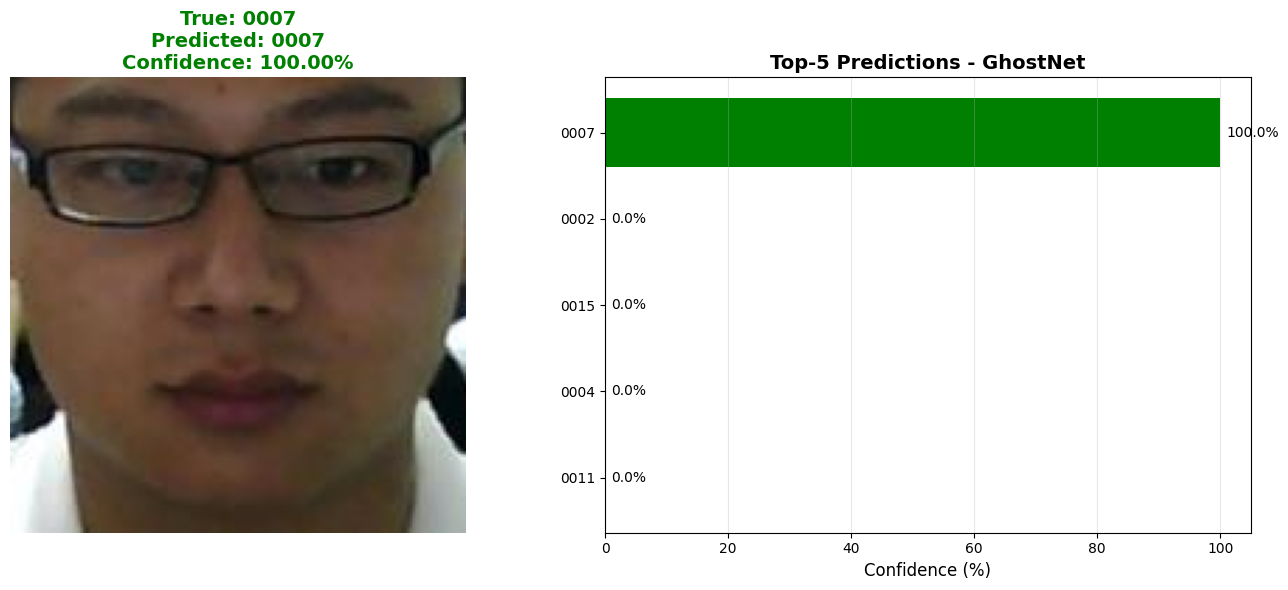

In [24]:
# Classify random image
result = classify_random_image(
    model_path="ghostnet_face_recognition.pth",
    dataset_path=r"C:\Users\cagan\Desktop\BachelorThesis\dataset\ClientFace",
    class_names=class_names,
    num_classes=num_classes,
    device=device
)